# Primer modelo baseline con regresión logística

## Objetivos de la sesión

En esta sesión se busca:

1. Cargar el dataset limpio preparado en la sesión anterior.
2. Separar variables predictoras y variable objetivo.
3. Dividir los datos en entrenamiento y prueba.
4. Construir un primer modelo baseline de regresión logística.
5. Obtener predicciones de clase y probabilidades.
6. Evaluar el desempeño del modelo con métricas básicas.
7. Interpretar los primeros resultados.

## Contexto

Después de la exploración y limpieza inicial del dataset, el siguiente paso natural es construir un modelo base que permita predecir si un cliente incurrirá en incumplimiento de pago en el siguiente mes.

La regresión logística es una elección adecuada para esta primera etapa porque es un modelo clásico de clasificación binaria, produce probabilidades interpretables y sirve como punto de comparación para modelos más complejos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Carga del dataset limpio

Se carga la versión depurada del conjunto de datos generada en la sesión anterior.

In [4]:
df = pd.read_csv("default_credit_clean.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month,SEX_LABEL,EDUCATION_LABEL,MARRIAGE_LABEL,AGE_GROUP
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Femenino,Universidad,Casado,20-29
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Femenino,Universidad,Soltero,20-29
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Femenino,Universidad,Soltero,30-39
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,Femenino,Universidad,Casado,30-39
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,Masculino,Universidad,Casado,50-59


 Revisión rápida de la estructura del dataset

In [5]:
print("Dimensiones:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

Dimensiones: (30000, 29)

Columnas:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_next_month', 'SEX_LABEL', 'EDUCATION_LABEL', 'MARRIAGE_LABEL', 'AGE_GROUP']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  30000 non-null  int64 
 1   LIMIT_BAL           30000 non-null  int64 
 2   SEX                 30000 non-null  int64 
 3   EDUCATION           30000 non-null  int64 
 4   MARRIAGE            30000 non-null  int64 
 5   AGE                 30000 non-null  int64 
 6   PAY_0               30000 non-null  int64 
 7   PAY_2               30000 non-null  int64 
 8   PAY_3               30000 non-null  int64 
 9   PAY_4               30000 non-null  int64 
 10  PAY_5               30000 non-null  int64 
 11  PAY_6               30000 non-null  int64 
 12  BILL_AMT1           30000 non-null  int64 
 13  BILL_AMT2           30000 non-null  int64 
 14  BILL_AMT3           30000 non-null  int64 
 15  BILL_AMT4           30000 non-null  int64 
 16  BILL_AMT5           30

## Separación de predictores y variable objetivo

La variable objetivo es `default_next_month`, mientras que el resto de las variables serán consideradas como predictores.

Se excluyen las columnas auxiliares de texto o etiquetas, así como el identificador `ID`.

In [8]:
cols_to_drop = ["default_next_month"]

optional_drop = ["ID", "SEX_LABEL", 'EDUCATION_LABEL', 'MARRIAGE_LABEL', 'AGE_GROUP' ]
for col in optional_drop:
    if col in df.columns:
        cols_to_drop.append(col)

X = df.drop(columns=cols_to_drop)
y = df["default_next_month"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (30000, 23)
Dimensiones de y: (30000,)


## Distribución de la variable objetivo

Antes de entrenar el modelo, es importante revisar qué tan balanceadas están las clases.

In [10]:
target_dist = y.value_counts().sort_index().to_frame("count")
target_dist["proportion"] = y.value_counts(normalize=True).sort_index()
target_dist

,count,proportion
default_next_month,,
0,23364,0.7788
1,6636,0.2212


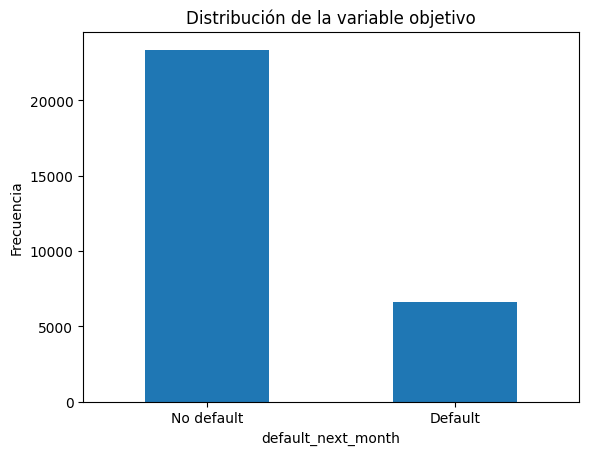

In [11]:
y.value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["No default", "Default"], rotation=0)
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable objetivo")
plt.show()

## División en entrenamiento y prueba

Se divide el conjunto de datos en dos partes:

- **entrenamiento**: para ajustar el modelo,
- **prueba**: para evaluar su desempeño en datos no vistos.

Se utiliza partición estratificada para conservar aproximadamente la misma proporción de clases en ambos subconjuntos.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (24000, 23)
X_test : (6000, 23)
y_train: (24000,)
y_test : (6000,)


* **`random_state=42` (Semilla de Aleatoriedad):** Su función es garantizar la **reproducibilidad**. Al fijar un número, aseguras que cada vez que ejecutes el código, los datos se mezclen exactamente igual. Sin esto, los resultados variarían en cada ejecución.
* **`stratify=y` (Muestreo Estratificado):** Mantiene la **misma proporción de clases** en los conjuntos de entrenamiento y prueba. Si el 22% de lostus datos originales son de la clase "Impago", el conjunto de prueba de 20% tendrá exactamente un 22% de clase impago. Vital para datos desbalanceados.


## Identificación de variables numéricas y categóricas

Para construir el pipeline de preprocesamiento, se distinguen las variables numéricas y categóricas.

In [13]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE", "AGE_GROUP"]
categorical_features = [col for col in categorical_features if col in X_train.columns]

numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("Variables categóricas:")
print(categorical_features)

print("\nVariables numéricas:")
print(numeric_features)

Variables categóricas:
['SEX', 'EDUCATION', 'MARRIAGE']

Variables numéricas:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


## Preprocesamiento

Se aplican transformaciones distintas según el tipo de variable:

- **numéricas**: imputación por mediana y escalamiento.
- **categóricas**: imputación por moda y codificación one-hot.

Este paso se integra en un pipeline para evitar fugas de información y mantener el flujo de trabajo ordenado.

In [15]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


#### Transformador Numérico (`numeric_transformer`)
Se encarga de las columnas con números (ej. 'LIMIT_BAL', 'AGE', 'PAY_0', etc.).
1. **`SimpleImputer(strategy="median")`**: Rellena los valores nulos (`NaN`) usando la **mediana** de la columna. Es más robusto ante valores atípicos (outliers) que el promedio.
2. **`StandardScaler()`**: Escala los datos para que tengan media 0 y desviación estándar 1. Evita que variables con magnitudes grandes dominen a las de números pequeños durante el entrenamiento.

#### Transformador Categórico (`categorical_transformer`)
Se encarga de las columnas de texto o categorías (ej. país, género).
1. **`SimpleImputer(strategy="most_frequent")`**: Rellena los valores nulos con la categoría más común (la moda).
2. **`OneHotEncoder(drop="first", handle_unknown="ignore")`**: Convierte texto en columnas binarias (0s y 1s).
   * `drop="first"`: Evita la multicolinealidad eliminando la primera columna de cada categoría generada.
   * `handle_unknown="ignore"`: Si aparecen categorías nuevas en los datos de prueba, el modelo las ignora llenando la fila con ceros, evitando errores en ejecución.

#### El Preprocesador Maestro (`ColumnTransformer`)
Es el orquestador que une las tuberías y las aplica al DataFrame original.
* Dirige las columnas listadas en `numeric_features` hacia el `numeric_transformer`.
* Dirige las columnas listadas en `categorical_features` hacia el `categorical_transformer`.

Usar estas estructuras automatizadas evita la **fuga de datos (data leakage)**, garantizando que estadísticas como la mediana se calculen *únicamente* con los datos de entrenamiento y se apliquen de forma ciega a los datos de prueba y datos futuros.

## Modelo baseline: regresión logística

Se construye una regresión logística como primer modelo baseline para predecir incumplimiento.

In [16]:
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

#### El Pipeline Principal (`Pipeline`)
Un `Pipeline` en Scikit-Learn garantiza que una serie de pasos se ejecuten en un orden estricto. La gran ventaja es que tratas a todo este conducto como si fuera un solo modelo. 

* **Paso 1: `"preprocessor", preprocessor`**:  `ColumnTransformer` que configuramos hace un momento". Esto limpiará los nulos, escalará los números y convertirá el texto en ceros y unos.
* **Paso 2: `"model", LogisticRegression(...)`**: Una vez que los datos salen limpios del preprocesador, entran directamente a este paso, que es el algoritmo de Machine Learning.

#### El Modelo (`LogisticRegression`)

* **`max_iter=2000` (Iteraciones máximas):** La Regresión Logística aprende intentando encontrar la mejor línea matemática para separar tus datos, ajustándose poco a poco en múltiples "intentos" (iteraciones). El valor por defecto de Scikit-Learn suele ser 100, lo cual a veces es muy poco y provoca un error molesto llamado `ConvergenceWarning` (significa que el modelo se rindió antes de encontrar la mejor respuesta). Al ponerlo en 2000, le das tiempo y espacio de sobra al algoritmo para que haga los cálculos necesarios hasta llegar a su mejor versión.
* **`random_state=42` (Semilla de aleatoriedad):** Igual que en la división de datos. Muchos algoritmos tienen pequeños componentes de azar al inicio de su entrenamiento. Fijar este número asegura que, si vuelves a correr el modelo mañana, el algoritmo tomará exactamente las mismas decisiones matemáticas y te dará el mismo resultado.

## Entrenamiento del modelo

In [17]:
log_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LIMIT_BAL', 'AGE', 'PAY_0',
                                                   'PAY_2', 'PAY_3', 'PAY_4',
                                                   'PAY_5', 'PAY_6',
                                                   'BILL_AMT1', 'BILL_AMT2',
                                                   'BILL_AMT3', 'BILL_AMT4',
                                                   'BILL_AMT5', 'BILL_AMT6',
                                                   'PAY_AMT1', 'PAY_AMT2',
                                                   'PAY_AMT3', 'PAY_AMT4',
                                                   'PAY_AMT5', 'PAY_AMT6']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['SEX', 'EDUCATION',
                                                   'MARRIAGE'])])),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

#### Contenedor Principal (`Pipeline`)
* **La caja grande con líneas punteadas:** Representa el objeto maestro final (el que llamamos `log_reg` en el último código). Todo lo que está dentro de esta caja se ejecuta como un solo bloque. Si entran datos crudos por arriba, salen predicciones por abajo.

#### División del Trabajo (`preprocessor: ColumnTransformer`)
* **La caja interior punteada:** Es tu `ColumnTransformer`. Actúa como un guardia de tráfico que separa tus datos iniciales en dos carriles distintos dependiendo de qué tipo de columna sean.

#### Los Dos Carriles Paralelos
* **Carril Izquierdo (`num`):** Las columnas con números viajan por aquí.
    * Primero pasan por el **`SimpleImputer`** (donde los huecos vacíos se rellenan con la mediana).
    * Luego pasan al **`StandardScaler`** (donde los números se nivelan para que no haya variables gigantes que opaquen a las pequeñas).
* **Carril Derecho (`cat`):** Las columnas con texto o categorías viajan por aquí.
    * Pasan por su propio **`SimpleImputer`** (donde los huecos se rellenan con la palabra más frecuente).
    * Luego entran al **`OneHotEncoder`** (donde el texto se transforma en columnas de 0s y 1s).

#### La Convergencia y el Cerebro (`LogisticRegression`)
* **La unión de las líneas:** Debajo de los carriles `num` y `cat`, las líneas grises se unen en una sola. Esto significa que los datos numéricos (ya limpios y escalados) y los datos categóricos (ya convertidos a 0s y 1s) se vuelven a fusionar en una sola tabla perfecta y ordenada.
* **La última parada:** Esa tabla limpia entra directamente a la caja de **`LogisticRegression`**. Este es el algoritmo de Machine Learning que analiza los datos procesados, aprende los patrones matemáticos y emite el resultado final (la predicción).

El diagrama confirma que el diseño funciona como un reloj. Cuando se utilice este modelo en el futuro, no tendremos que aplicar los pasos uno por uno; simplemente le damos la tabla cruda al inicio del mapa, y el sistema seguirá esta ruta automáticamente hasta dar la respuesta al final.

## Predicciones del modelo

Se obtienen:

- predicciones de clase (`0` o `1`),
- probabilidades estimadas de incumplimiento.

In [18]:
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

#### `predict(X_test)`: La decisión final 
* Esta función obliga al modelo a tomar una decisión absoluta. El modelo analiza cada fila de `X_test` y devuelve la etiqueta final calculada (por ejemplo, `0` o `1`, "No impago" o "Impago").

* Por defecto, la Regresión Logística usa un umbral (threshold) del 50%. Si cree que hay más de un 50% de probabilidad de que sea clase `1`, predice `1`. Si es menos, predice `0`.


#### `predict_proba(X_test)[:, 1]`: El nivel de seguridad 
* En lugar de dar un veredicto final, `predict_proba` (que significa *Predict Probabilities*) te dice qué tan seguro está el modelo de su decisión en forma de porcentaje (de 0.0 a 1.0).
* `[:, 1]` al final es un truco de la librería NumPy. Cuando haces una predicción binaria (dos opciones), Scikit-Learn te devuelve una tabla con **dos columnas**:
    * Columna 0: Probabilidad de que sea clase `0` (Ej. 20% o 0.20)
    * Columna 1: Probabilidad de que sea clase `1` (Ej. 80% o 0.80)
    * Al escribir `[:, 1]`, le estás diciendo a Python: *"Tráeme todas las filas (`:`), pero **solo la columna del índice 1**"*. La clase 1 es la que nos interesa detectar (Impago).

## Evaluación del modelo

Se calculan métricas básicas para evaluar el desempeño del clasificador en el conjunto de prueba.

In [19]:
metrics_dict = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

pd.DataFrame(metrics_dict, index=["Logistic Regression"]).T

,Logistic Regression
Accuracy,0.8092
Precision,0.6953
Recall,0.2442
F1-score,0.3614
ROC-AUC,0.7099


In [20]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.8188    0.9696    0.8878      4673
           1     0.6953    0.2442    0.3614      1327

    accuracy                         0.8092      6000
   macro avg     0.7570    0.6069    0.6246      6000
weighted avg     0.7914    0.8092    0.7714      6000



#### `accuracy` (Exactitud)
* **Valor:** **`0.8092` (80.9%)**
* De las 6,000 personas totales evaluadas, el modelo acertó en el 81% de los casos.
* Como casi el 78% de los clientes son buenos pagadores, el modelo podría simplemente predecir "Nadie va a impagar" y aun así sacaría casi un 78% de exactitud. El `accuracy` oculta que el modelo es muy malo detectando la Clase 1.


#### La Clase 1 (Impago)
Aquí es donde se previene la pérdida de dinero.

* **`support` (1327):** Había 1,327 personas en estos datos que **realmente no pagaron**.
* **`recall` (0.2442 o 24.4%):** *El mayor problema del modelo.*
    * De esos 1,327 morosos reales, el modelo **solo logró detectar a 324**.
    * A los otros 1,003 morosos se les escapó la alarma, el banco les aprobó la tarjeta y generaron pérdidas (*Falsos Negativos*).
* **`precision` (0.6953 o 69.5%):** * **Traducción:** Cuando el modelo levanta una alerta y dice "Este cliente no va a pagar", tiene razón el 69.5% de las veces.
    * **Impacto:** El otro 30.5% de las veces, se equivoca y acusa a un buen cliente de ser moroso, lo que significa que el banco le niega la tarjeta a alguien que sí iba a pagar (*Falsos Positivos*).
* **`f1-score` (0.3614):** * Es el promedio armónico entre `precision` y `recall`. Como el modelo es tan ciego para encontrar morosos (bajo recall), esta calificación general se hunde a 0.36. Es un claro "reprobado" para detectar la clase minoritaria.


#### La Clase 0 (Buen pagador)
El modelo es un experto en esta clase porque vio muchísimos más ejemplos de ella durante su entrenamiento.

* **`support` (4673):** Personas que realmente pagaron a tiempo.
* **`recall` (0.9696 o 97.0%):** De los 4,673 buenos clientes, el modelo identificó correctamente al 97%. Casi no se le escapa ninguno.
* **`precision` (0.8188 o 81.9%):** Cuando el modelo dice "Es un buen cliente", acierta casi el 82% de las veces.


#### Los Promedios Finales
* **`macro avg` (Promedio Macro):** Calcula el promedio simple entre la Clase 0 y la Clase 1, tratando a ambas por igual sin importar cuántos clientes haya en cada una. Es el indicador más honesto en datos desbalanceados. Muestra un F1-Score real de **0.6246**, lo cual indica un modelo mediocre.
* **`weighted avg` (Promedio Ponderado):** Toma el promedio, pero le da mucha más importancia a la Clase 0 porque tiene más clientes (4673 vs 1327). Falsamente infla los números haciendo parecer que el modelo tiene un rendimiento del **77%**.

### Resumen 
El modelo es excelente para darle la bienvenida a los buenos clientes (Clase 0), pero es demasiado conservador y casi ciego ante el riesgo (Clase 1). Deja pasar a casi el 75% de los morosos sin detectarlos. 


## Matriz de confusión

La matriz de confusión resume los aciertos y errores del modelo en cada clase.

In [22]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Real: No default", "Real: Default"],
    columns=["Pred: No default", "Pred: Default"]
)
cm_df

,Pred: No default,Pred: Default
Real: No default,4531,142
Real: Default,1003,324


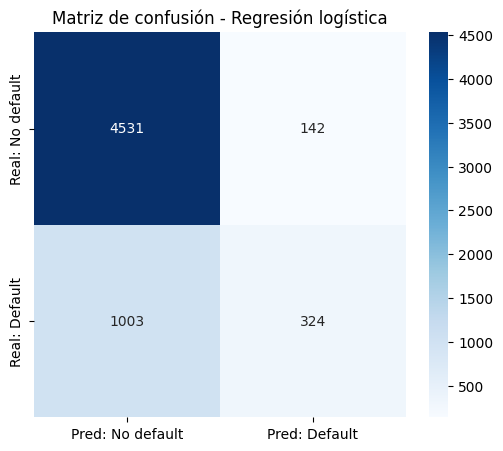

In [26]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Regresión logística")
plt.show()

#### Los Aciertos (La diagonal principal)
Estos son los casos donde el modelo hizo un buen trabajo.

* **Cuadrante Superior Izquierdo (4,531) - Verdaderos Negativos:** * El modelo predijo que **No** harían impago ("No default"), y en la vida real **No** hicieron impago.
  * El banco les dio la tarjeta de crédito, los clientes pagaron a tiempo y el banco ganó dinero. Este es el número más grande porque la base de datos está llena de buenos clientes.
* **Cuadrante Inferior Derecho (324) - Verdaderos Positivos:**
  * El modelo predijo que **Sí** harían impago ("Default"), y en la vida real efectivamente **Sí** iban a fallar.
  * El banco confió en el modelo, les negó la tarjeta y se salvó de perder dinero con estas 324 personas.


#### Los Errores (Donde perdemos dinero u oportunidades)
Aquí es donde el modelo se confunde (por eso se llama matriz de confusión).

* **Cuadrante Superior Derecho (142) - Falsos Positivos (Falsas Alarmas):**
  * El modelo se asustó y predijo **Default**, pero en realidad el cliente era bueno (**No default**).
  * El banco le negó la tarjeta a 142 personas que sí iban a pagar. Es una **pérdida de oportunidad comercial**, pero financieramente no es tan grave como prestar dinero y no recuperarlo.
* **Cuadrante Inferior Izquierdo (1,003) - Falsos Negativos (El Punto Ciego):**
  * El modelo se relajó y predijo que todo estaba bien (**No default**), pero en realidad estas personas **Sí** hicieron impago (**Default**).
  * Este es el desastre financiero. El banco le prestó dinero a 1,003 personas pensando que eran buenos clientes, y ninguno pagó. 


## Curva ROC

La curva ROC permite evaluar la capacidad discriminante del modelo en diferentes umbrales de clasificación.

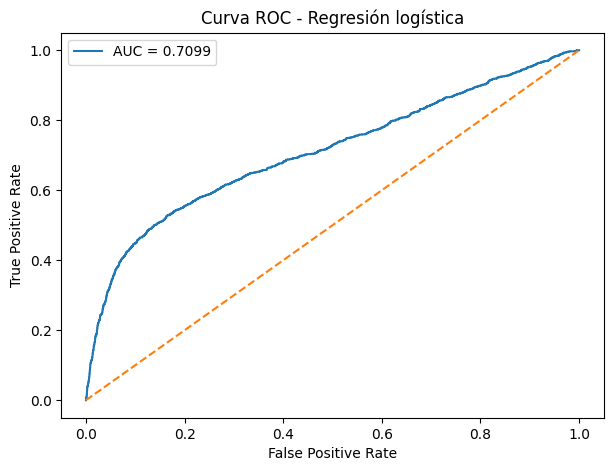

In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión logística")
plt.legend()
plt.show()

La línea diagonal naranja representa un modelo inútil que adivina al azar, mientras que la línea azul demuestra que el algoritmo sí ha aprendido patrones reales al lograr elevarse por encima de ella. El indicador definitivo aquí es el AUC = 0.7099 (Área Bajo la Curva), lo que significa que si tomas a un cliente moroso y a un buen cliente al azar, tu modelo tiene un 71% de probabilidad de asignarle un mayor nivel de riesgo al moroso. En la industria financiera, un AUC de 0.71 se considera apenas "aceptable" o regular; confirma que el modelo tiene potencial, pero reitera la conclusión de que se necesita aplicar técnicas de balanceo de datos para empujar esa curva más hacia la esquina superior izquierda (la zona de perfección) y hacerlo verdaderamente seguro para el banco.

## Ejemplos de probabilidades predichas

Se revisan algunas probabilidades estimadas por el modelo para interpretar qué significa una salida probabilística.

In [29]:
results = X_test.copy()
results["y_real"] = y_test.values
results["y_pred"] = y_pred
results["prob_default"] = y_proba

print(results[["y_real", "y_pred", "prob_default"]].head(10))

       y_real  y_pred  prob_default
6907        0       0        0.1067
24575       0       0        0.1182
26766       0       0        0.2207
2156        1       0        0.0954
3179        0       0        0.0294
29382       0       0        0.2099
24454       0       0        0.1318
23886       0       0        0.1604
5504        0       0        0.0760
29720       0       0        0.2011


Este bloque de código y su salida son la "prueba del delito" que confirma todo lo que hemos venido analizando. Al unir la realidad (`y_real`), la decisión final (`y_pred`) y la probabilidad matemática (`prob_default`), podemos ver exactamente cómo "piensa" el modelo caso por caso.


#### El veredicto invisible: El Umbral del 50%
En la columna `y_pred`, **todos los valores son 0**. 
Porque por defecto, la función `.predict()` de Scikit-Learn tiene una regla inquebrantable: *"Solo voy a decir que es un impago (1) si la probabilidad (`prob_default`) es estrictamente **mayor al 50% (0.50)**"*. La probabilidad más alta en esta muestra de 10 clientes es la del cliente `26766` con un `0.2207` (22%). Ninguno se acerca siquiera al 50%, por lo tanto, el modelo los clasifica a todos como buenos clientes (`0`).

### El caso de estudio del desastre: El Cliente 2156
Miremos con atención la fila con el índice **2156**. Es el ejemplo perfecto del problema de negocio que detectamos antes:

* **`y_real = 1`:** En la vida real, este cliente **no pagó su tarjeta**. Es un moroso.
* **`prob_default = 0.0954`:** El modelo evaluó su historial y calculó que solo tenía un **9.5%** de probabilidad de impago.
* **`y_pred = 0`:** Como 9.5% es mucho menor que el 50% exigido, el modelo predijo ciegamente que era un buen cliente. 

Esto es exactamente un **Falso Negativo**. Por culpa de esta decisión, el banco le dio crédito a esa persona y perdió dinero. Y vimos en tu matriz de confusión que este error se repitió 1,003 veces.

### El sesgo hacia el cero es evidente
Esta tabla de 10 clientes demuestra visualmente el efecto del desbalance de datos (78% vs 22%). El modelo es tan "conservador" y está tan acostumbrado a ver ceros, que sus probabilidades calculadas son extremadamente bajas en general (van del 2% al 22%). 

### ¿Cómo lo arreglamos cambiando el umbral?
En los bancos, raras veces se usa el umbral automático del 50%. Los equipos de riesgos bajan ese umbral manualmente para hacer al modelo más sensible y "paranoico". 

En esta etapa, el objetivo principal no es obtener el mejor modelo posible, sino construir un baseline interpretable que sirva como punto de referencia para comparaciones futuras.

## Inspección preliminar de coeficientes

En regresión logística, los coeficientes indican la dirección de la asociación entre cada predictor y la probabilidad de incumplimiento, manteniendo fijas las demás variables.

Esta interpretación debe hacerse con cautela, especialmente después de transformaciones y codificación de variables categóricas.

In [31]:
feature_names_num = numeric_features

ohe = log_reg.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
feature_names_cat = ohe.get_feature_names_out(categorical_features)

feature_names = np.concatenate([feature_names_num, feature_names_cat])

coefficients = log_reg.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

print(coef_df.head(15))

      feature  coefficient
2       PAY_0       0.6606
9   BILL_AMT2       0.1012
4       PAY_3       0.0951
3       PAY_2       0.0916
5       PAY_4       0.0604
1         AGE       0.0566
11  BILL_AMT4       0.0499
12  BILL_AMT5       0.0415
10  BILL_AMT3       0.0341
7       PAY_6       0.0157
6       PAY_5      -0.0006
13  BILL_AMT6      -0.0186
18   PAY_AMT5      -0.0189
19   PAY_AMT6      -0.0293
16   PAY_AMT3      -0.0333


Mientras que los pasos anteriores nos decían *qué tan bien* funcionaba el modelo, este bloque de código nos dice **por qué toma las decisiones que toma**.

* Como el `OneHotEncoder` transformó tus categorías de texto en múltiples columnas nuevas de ceros y unos, los nombres originales de las columnas cambiaron. Las primeras tres líneas del código se meten al preprocesador, extraen los nombres exactos de las nuevas columnas y los unen con las columnas numéricas (`np.concatenate`).
  
* `log_reg.named_steps["model"].coef_[0]` entra al cerebro de la Regresión Logística y extrae los "coeficientes" (los pesos multiplicadores) que el algoritmo le asignó a cada variable después de entrenar.

#### ¿Cómo se leen los Coeficientes? (El impacto en el negocio)
En la Regresión Logística, el modelo decide si alguien va a hacer impago (Clase 1) sumando puntos. Cada variable suma o resta puntos de riesgo.

* **Coeficientes Positivos (+):** Son **Factores de Riesgo**. Aumentan la probabilidad de que el cliente caiga en Impago. Mientras más grande sea el número, más peligroso es.
  
* **Coeficientes Negativos (-):** Son **Factores de Protección**. Disminuyen la probabilidad de impago. Empujan al modelo a clasificar al cliente como un buen pagador (0).

* **Coeficientes cerca de cero (0.00x):** Son variables que al modelo no le importan casi nada. Son "ruido" que no ayuda ni perjudica.


#### Análisis de tus Resultados 

El modelo ha descubierto patrones de negocio muy claros:

**A. El Factor de Riesgo Absoluto: `PAY_0` (0.6606)**
* Este es el rey indiscutible de tu modelo. Su peso (0.66) es más de 6 veces mayor que el de la segunda variable. 
* En este dataset, `PAY_0` representa el **estado de pago del mes más reciente**. 
* **El aprendizaje del modelo:** *"No me importa mucho el historial antiguo. Si el cliente ya presenta retrasos en el mes actual (`PAY_0`), las alarmas rojas deben encenderse a su máxima potencia porque es casi seguro que hará impago el próximo mes"*.

**B. El peso de las deudas recientes: `PAY_2`, `PAY_3`, `PAY_4`**
* Los historiales de pago de los meses anteriores también tienen un peso positivo fuerte (entre 0.06 y 0.09). Cada mes consecutivo de retraso en los pagos va sumando puntos a la probabilidad de que la bomba explote (el impago definitivo).

**C. Los montos facturados: `BILL_AMT2`, `BILL_AMT4`...**
* Curiosamente, los montos de la factura tienen pesos positivos bajitos pero constantes. Esto sugiere que a mayor cantidad de dinero que se debe en las tarjetas de crédito, ligeramente mayor es el riesgo de asfixia financiera e impago.

**D. Los Factores de Protección (Los números negativos)**
* En los últimos lugares de la tabla: `PAY_AMT3 (-0.0333)`, `PAY_AMT6 (-0.0293)`, `PAY_AMT5 (-0.0189)`.
* Las variables `PAY_AMT` representan **la cantidad de dinero que el cliente sí abonó/pagó** en meses anteriores.
* **El aprendizaje del modelo:** *"Mientras más dinero en efectivo haya depositado el cliente en su tarjeta recientemente, le restaré puntos al riesgo"*. El modelo entiende que un historial de abonos altos es un síntoma de buena salud financiera.

### Conclusión del Análisis
El modelo no es una caja negra; tiene mucho sentido financiero. Ha aprendido por su cuenta que el comportamiento de pago más reciente (`PAY_0`) es el mejor indicador del futuro, y que hacer abonos grandes a la cuenta (`PAY_AMT`) reduce el riesgo. Esta tabla es oro puro porque se la puedes llevar al equipo de negocios o riesgos para explicarles exactamente en qué se fija la inteligencia artificial antes de rechazar una tarjeta.

## Conclusiones de la sesión

En esta sesión se construyó el primer modelo baseline del proyecto usando regresión logística.

Los principales avances fueron:

1. Se cargó y organizó el dataset limpio.
2. Se separaron predictores y variable objetivo.
3. Se dividieron los datos en entrenamiento y prueba.
4. Se implementó un pipeline de preprocesamiento para variables numéricas y categóricas.
5. Se entrenó una regresión logística.
6. Se evaluó el modelo con métricas de clasificación y curva ROC.
7. Se interpretaron las probabilidades predichas como estimaciones del riesgo de incumplimiento.

Este modelo servirá como referencia inicial para comparar posteriormente con modelos más flexibles o potentes, como árboles de decisión, Random Forest o Gradient Boosting.